# Evaluación de métodos de similitud sobre los datasets A-E

Este notebook mide el desempeño de los 6 métodos implementados (`ted`, `mdiff`,
`lf`, `gst`, `trs`, `csim`) contra los 5 datasets etiquetados con la
metodología Faidhi (`notebooks/datasets/{A,B,C,D,E}`), usando la validación
humana como filtro de calidad del ground truth.

**Regla de uso de una fila:** un par solo entra al cálculo de métricas si la
columna `Human_Label` (llenada con `tools/pair_validator`) coincide con la
columna `Label` original. Si no coinciden, el par se descarta: significa que
un humano revisó ese par y no está de acuerdo con la etiqueta, así que no es
un ground truth confiable para medir a los métodos.

Antes de correr esto con datos reales, `prepare_validated_datasets.py` debe
haberse corrido (por defecto genera un placeholder donde `Human_Label = Label`
en todas las filas, es decir "sin validar todavía" - todas las filas quedan
usables mientras tanto).

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from scsc import Compare


In [2]:
# Rutas y constantes
HERE = os.path.abspath(os.getcwd())
DATASETS_DIR = os.path.join(HERE, "..", "datasets")
VALIDATED_DIR = os.path.join(HERE, "validated_datasets")

DATASET_LETTERS = ["A", "B", "C", "D", "E"]
METHODS = ["ted", "mdiff", "lf", "gst", "trs", "csim"]
THRESHOLD = 0.70  # score >= THRESHOLD se clasifica como par similar (1)

METHOD_COLORS = dict(zip(METHODS, sns.color_palette("tab10", len(METHODS))))

all_results = {}  # all_results[dataset_letter][method] = resultado de evaluate_method


## Funciones auxiliares

In [3]:
def load_usable_pairs(letter):
    """Carga <letter>_dataset_validated.csv y descarta filas donde la
    validación humana no coincide con la etiqueta original."""
    csv_path = os.path.join(VALIDATED_DIR, f"{letter}_dataset_validated.csv")
    df = pd.read_csv(csv_path)
    total = len(df)

    verified = df["Human_Label"].notna() & (df["Human_Label"] == df["Label"])
    usable = df[verified].reset_index(drop=True)

    print(f"Dataset {letter}: {len(usable)}/{total} pares verificados positivamente (usables).")
    return usable


In [4]:
def evaluate_method(df, files_dir, method, threshold=THRESHOLD):
    """Corre `method` sobre cada par de df y mide tiempo total de ejecución."""

    def read(path):
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            return f.read()

    truth_values = df["Label"].tolist()
    predicted_values = []
    scores = []

    start = time.time()
    for row in df.itertuples():
        content1 = read(os.path.join(files_dir, row.File_1))
        content2 = read(os.path.join(files_dir, row.File_2))
        score = Compare(content1, content2, method=method)
        scores.append(score)
        predicted_values.append(1 if score >= threshold else 0)
    elapsed = time.time() - start

    misclassified = [
        (df.iloc[i]["File_1"], df.iloc[i]["File_2"])
        for i, (t, p) in enumerate(zip(truth_values, predicted_values))
        if t != p
    ]

    return {
        "truth": truth_values,
        "pred": predicted_values,
        "scores": scores,
        "time": elapsed,
        "n": len(truth_values),
        "misclassified": misclassified,
    }


In [5]:
def calculate_metrics(true_values, predicted_values):
    # Labels en orden [1, 0] para mantener consistencia en la matriz de confusión
    matrix = confusion_matrix(true_values, predicted_values, labels=[1, 0])
    accuracy = accuracy_score(true_values, predicted_values)
    precision = precision_score(true_values, predicted_values, zero_division=0)
    recall = recall_score(true_values, predicted_values, zero_division=0)
    f1 = f1_score(true_values, predicted_values, zero_division=0)
    return matrix, accuracy, precision, recall, f1


def plot_confusion_matrix(true_values, predicted_values, title=None, normalize=False, show_metrics=True):
    matrix, accuracy, precision, recall, f1 = calculate_metrics(true_values, predicted_values)

    if normalize:
        row_sums = matrix.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        display_matrix = matrix.astype(float) / row_sums
        fmt = ".2f"
        cbar_label = "Proporción"
    else:
        display_matrix = matrix
        fmt = "d"
        cbar_label = "Conteos"

    df_cm = pd.DataFrame(
        display_matrix,
        index=["Positivos Reales", "Negativos Reales"],
        columns=["Positivos Predichos", "Negativos Predichos"],
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_cm, annot=True, fmt=fmt, cmap="Blues", cbar_kws={"label": cbar_label})
    plt.xlabel("Valores Predichos")
    plt.ylabel("Valores Reales")

    full_title = f"Matriz de Confusión | {title}" if title else "Matriz de Confusión"
    if show_metrics:
        full_title += f"\nAccuracy {accuracy:.2f} | Precision: {precision:.2f} | Recall: {recall:.2f} | F1: {f1:.2f}"
    plt.title(full_title)
    plt.tight_layout()
    plt.show()


In [6]:
def plot_metrics_comparison(dataset_letter, results_by_method):
    """Un grupo de barras por métrica (Accuracy/Precision/Recall/F1), una barra por método."""
    metrics_names = ["Accuracy", "Precision", "Recall", "F1"]
    method_names = list(results_by_method.keys())

    data = {}
    for m in method_names:
        _, acc, prec, rec, f1 = calculate_metrics(results_by_method[m]["truth"], results_by_method[m]["pred"])
        data[m] = [acc, prec, rec, f1]

    x = np.arange(len(metrics_names))
    width = 0.8 / len(method_names)

    plt.figure(figsize=(10, 6))
    for i, m in enumerate(method_names):
        plt.bar(x + i * width, data[m], width, label=m, color=METHOD_COLORS.get(m))

    plt.xticks(x + width * (len(method_names) - 1) / 2, metrics_names)
    plt.ylim(0, 1.05)
    plt.ylabel("Valor")
    plt.title(f"Comparación de métricas por método | Dataset {dataset_letter}")
    plt.legend(title="Método", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_time_comparison(dataset_letter, results_by_method):
    method_names = list(results_by_method.keys())
    times = [results_by_method[m]["time"] for m in method_names]
    colors = [METHOD_COLORS.get(m) for m in method_names]
    n_pairs = results_by_method[method_names[0]]["n"]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(method_names, times, color=colors)
    plt.ylabel("Tiempo de ejecución (s)")
    plt.title(f"Tiempo de ejecución por método | Dataset {dataset_letter} ({n_pairs} pares)")
    for b, t in zip(bars, times):
        plt.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{t:.2f}s", ha="center", va="bottom", fontsize=9)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [7]:
def run_dataset_evaluation(letter):
    print(f"=== Dataset {letter} ===")
    df = load_usable_pairs(letter)
    files_dir = os.path.join(DATASETS_DIR, letter)

    results = {}
    for method in METHODS:
        res = evaluate_method(df, files_dir, method)
        results[method] = res
        n_bad = len(res["misclassified"])
        print(f"  {method:6s}: {res['time']:6.2f}s  ({n_bad} pares mal clasificados)")

    all_results[letter] = results

    for method in METHODS:
        plot_confusion_matrix(
            results[method]["truth"], results[method]["pred"],
            title=f"Dataset {letter} | {method}",
        )

    plot_metrics_comparison(letter, results)
    plot_time_comparison(letter, results)
    return results


## Dataset A

=== Dataset A ===
Dataset A: 72/72 pares verificados positivamente (usables).
  ted   :   0.05s  (9 pares mal clasificados)
  mdiff :   0.07s  (0 pares mal clasificados)


  lf    :   0.35s  (15 pares mal clasificados)
  gst   :   0.06s  (15 pares mal clasificados)
  trs   :   0.05s  (21 pares mal clasificados)


  csim  :   0.79s  (2 pares mal clasificados)


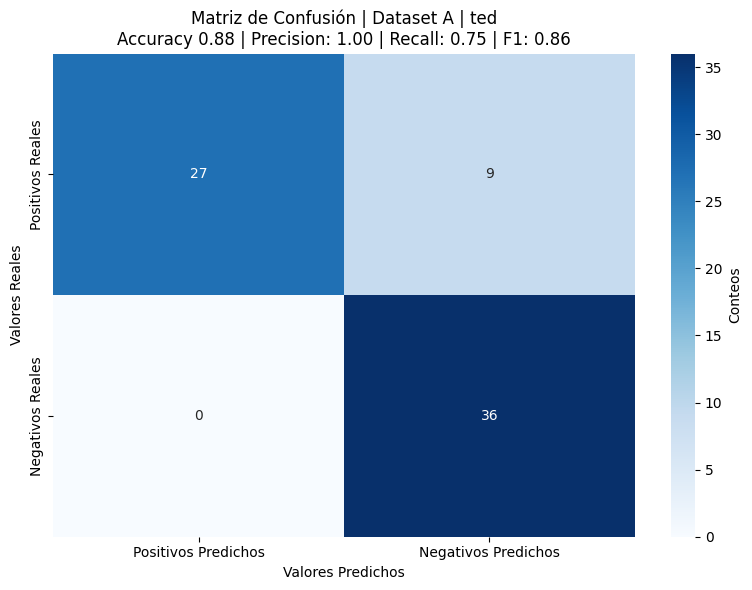

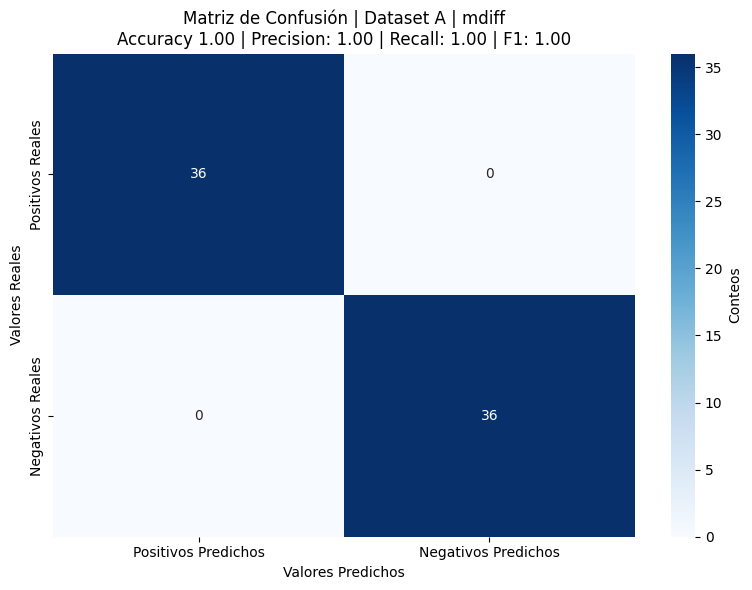

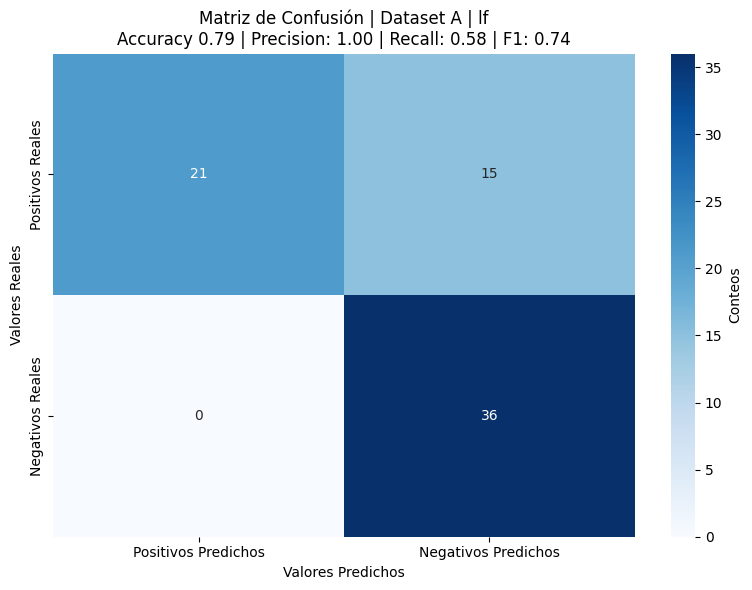

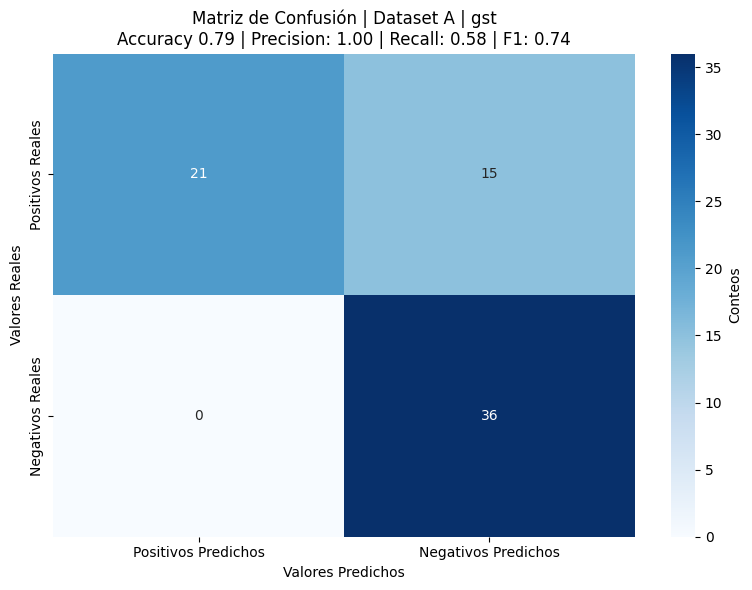

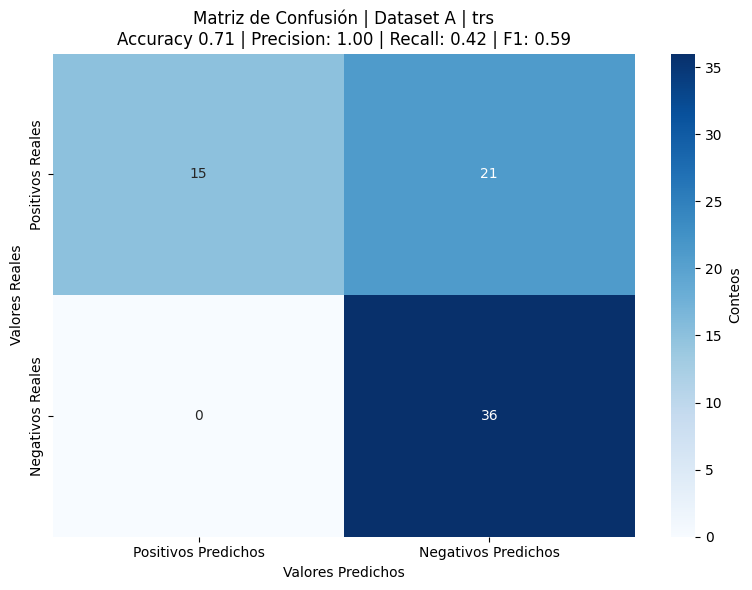

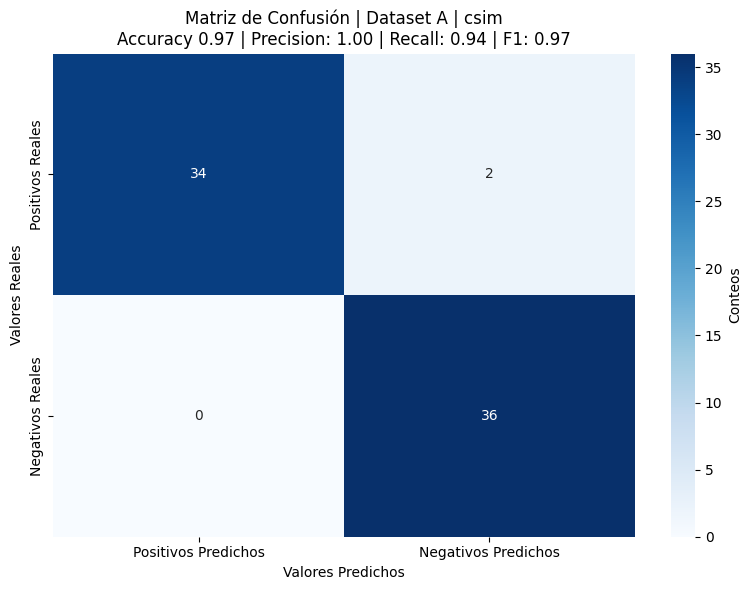

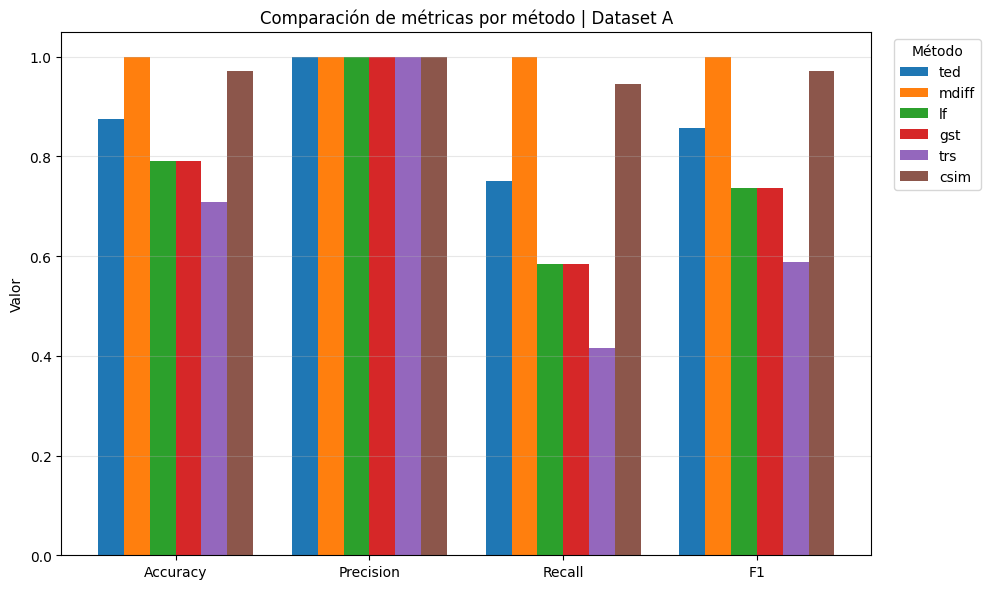

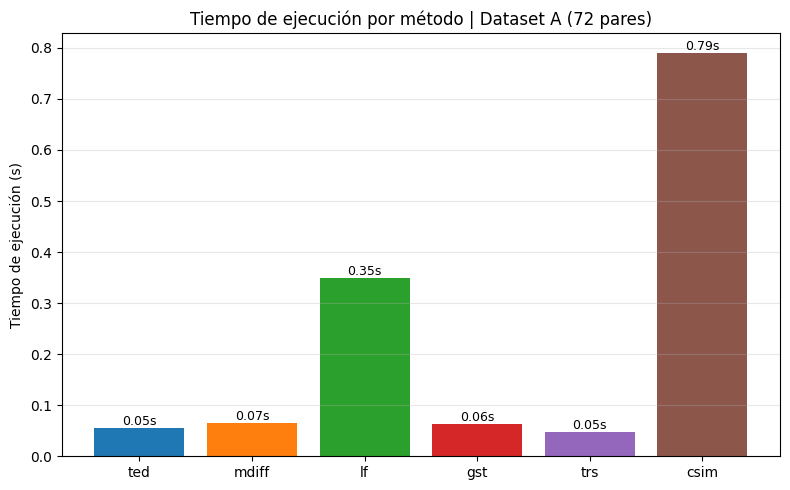

In [8]:
_ = run_dataset_evaluation("A")

## Dataset B

=== Dataset B ===
Dataset B: 72/72 pares verificados positivamente (usables).
  ted   :   0.10s  (28 pares mal clasificados)


  mdiff :   0.14s  (20 pares mal clasificados)


  lf    :   0.37s  (14 pares mal clasificados)


  gst   :   0.53s  (14 pares mal clasificados)
  trs   :   0.09s  (10 pares mal clasificados)


  csim  :   1.83s  (16 pares mal clasificados)


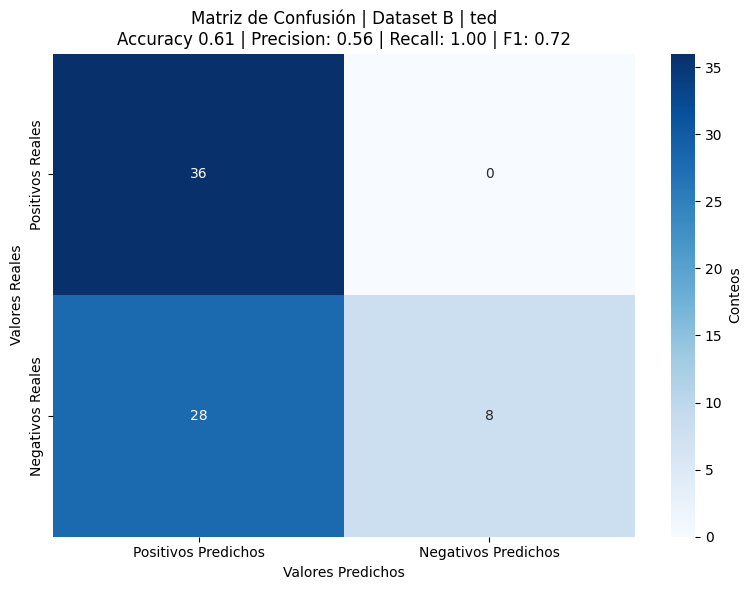

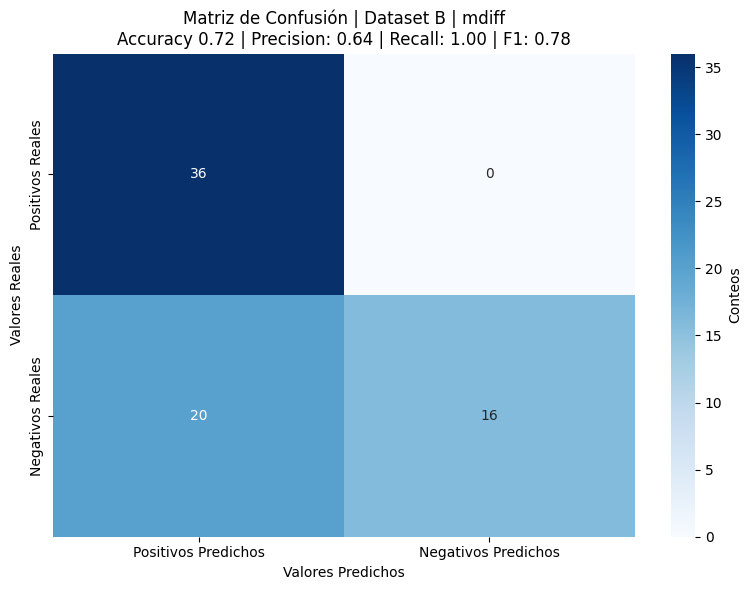

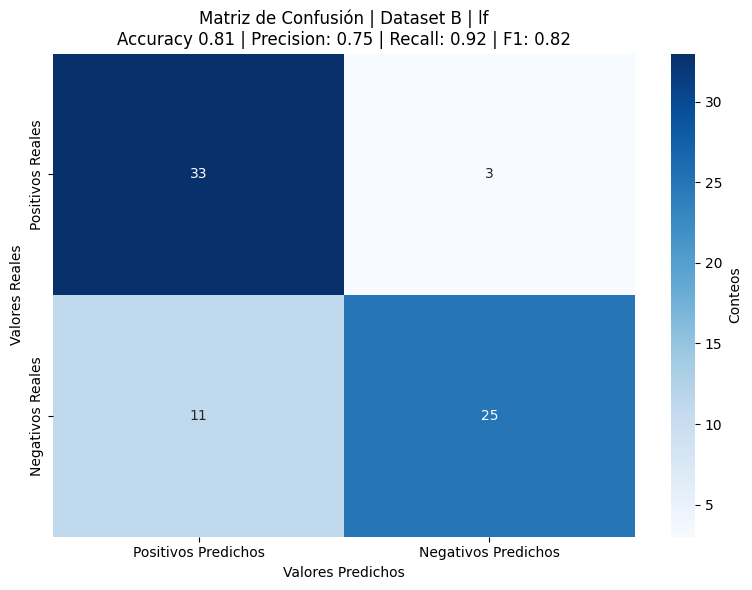

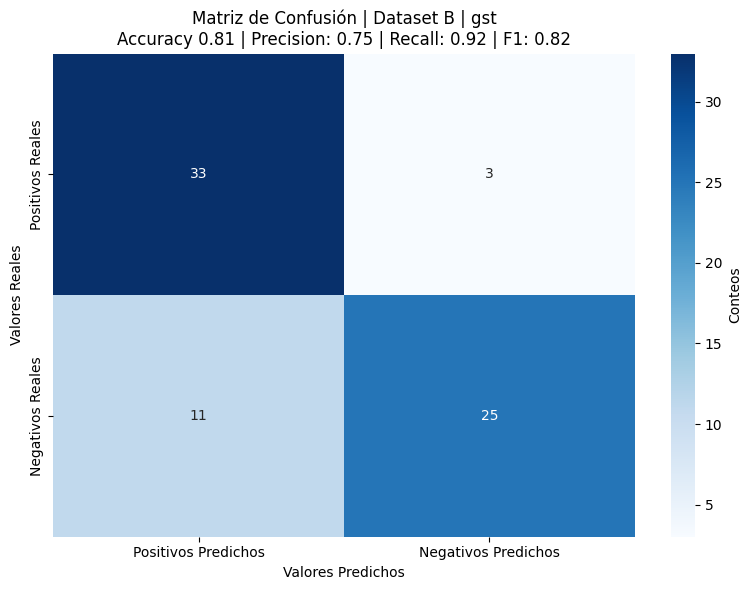

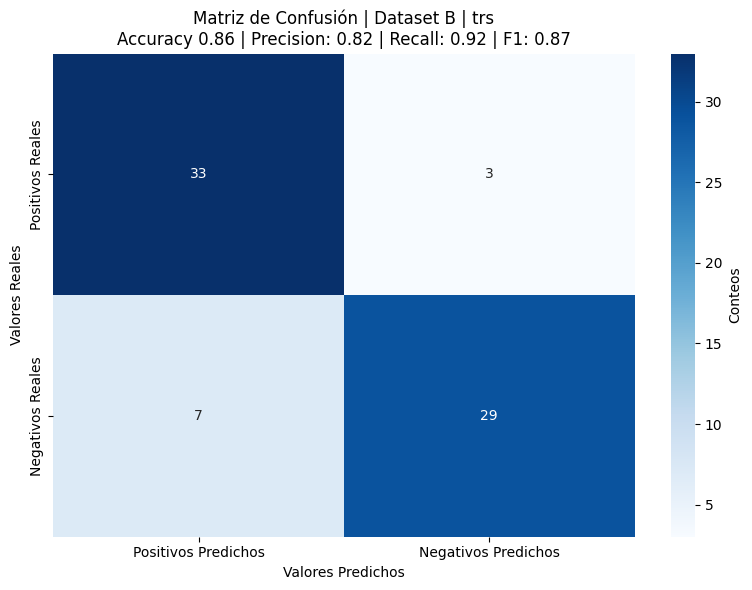

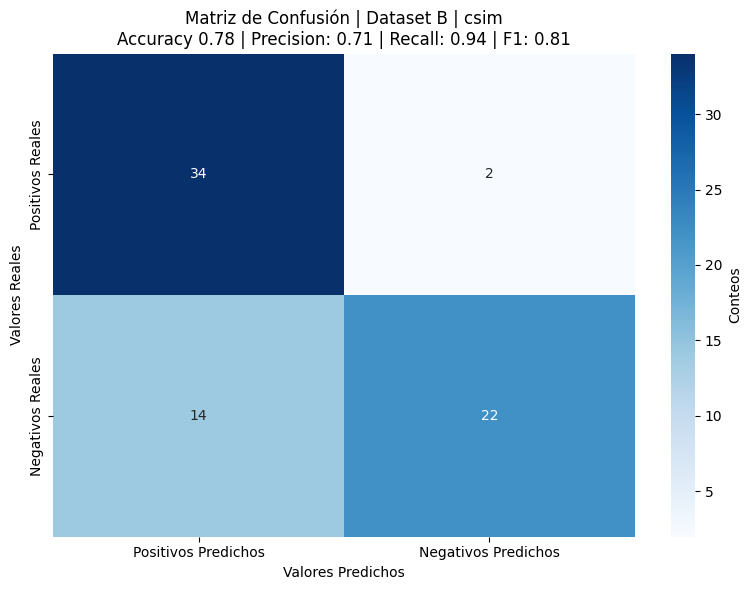

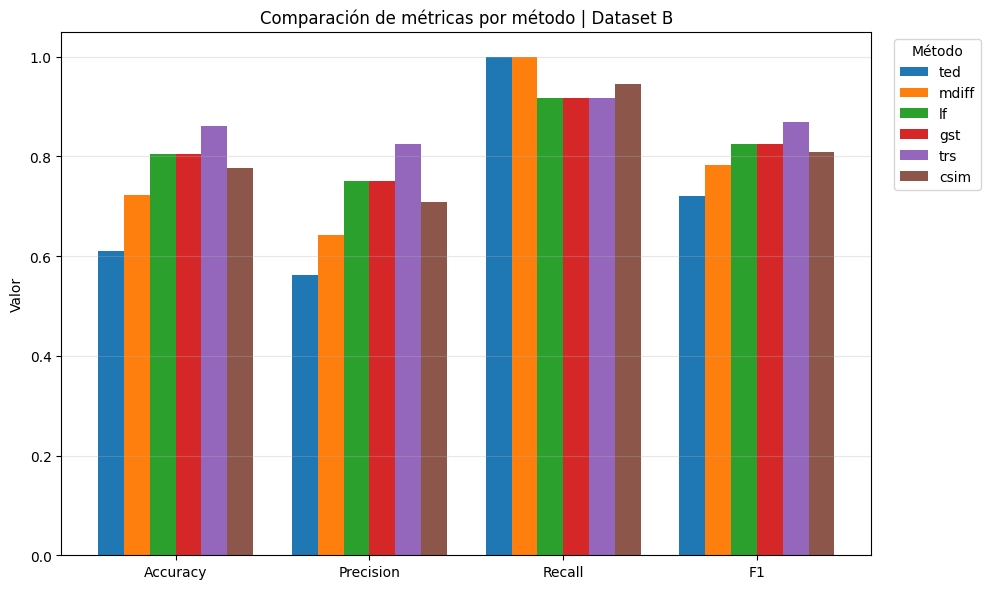

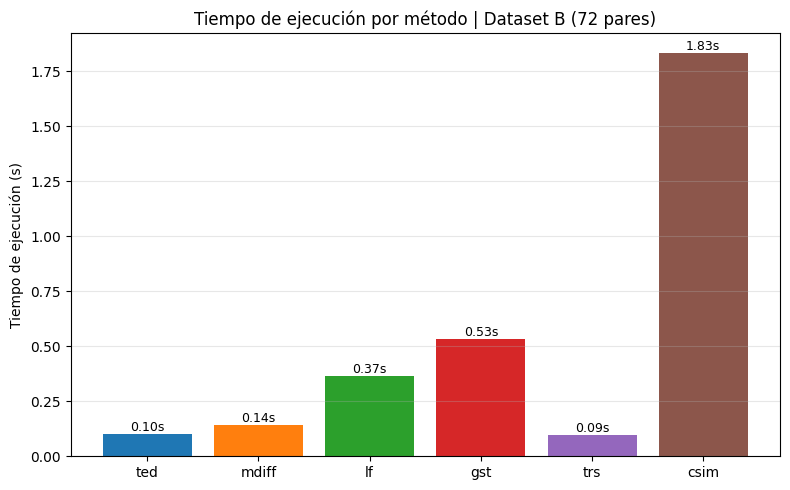

In [9]:
_ = run_dataset_evaluation("B")

## Dataset C

=== Dataset C ===
Dataset C: 140/140 pares verificados positivamente (usables).
  ted   :   0.07s  (7 pares mal clasificados)
  mdiff :   0.07s  (26 pares mal clasificados)


  lf    :   0.51s  (25 pares mal clasificados)
  gst   :   0.09s  (11 pares mal clasificados)
  trs   :   0.06s  (14 pares mal clasificados)


  csim  :   0.47s  (9 pares mal clasificados)


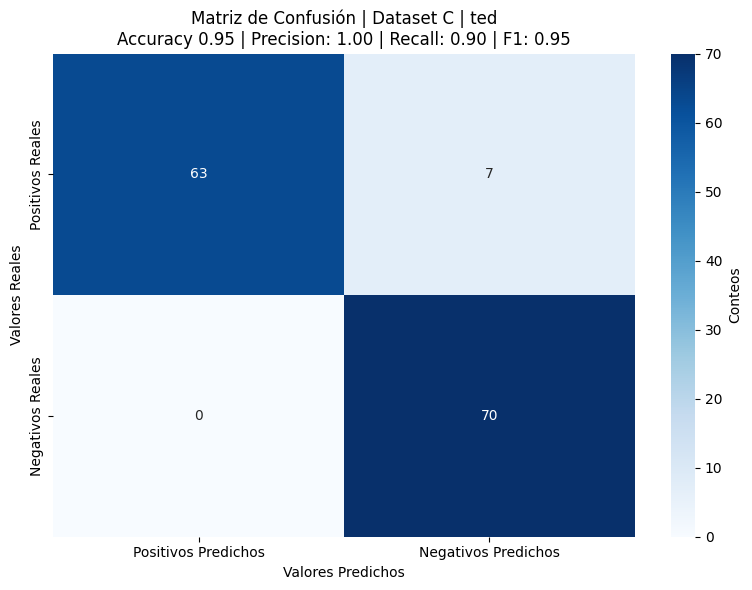

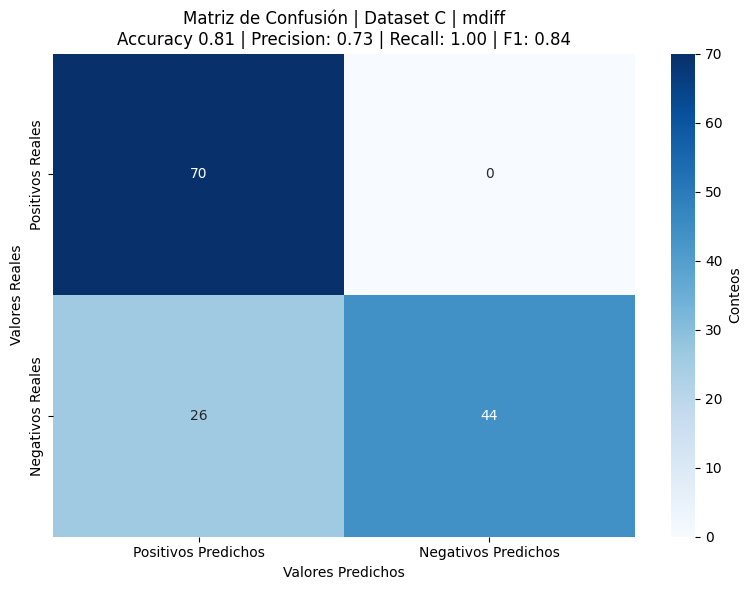

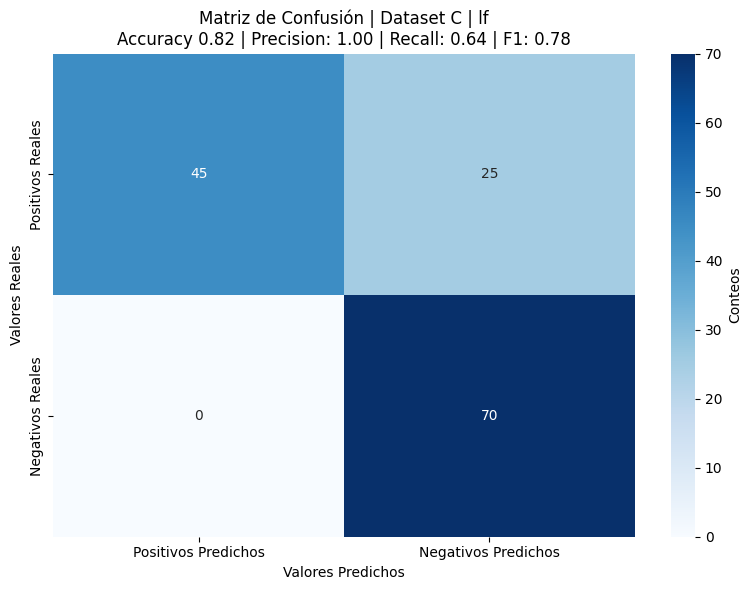

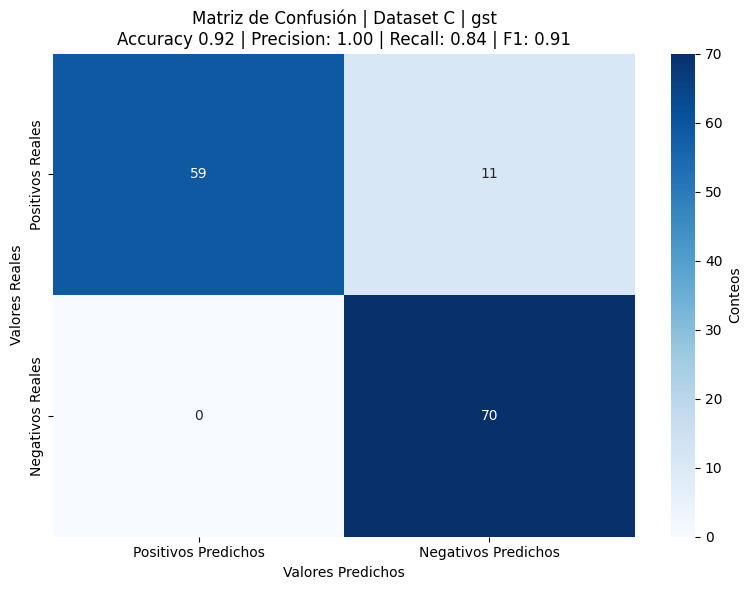

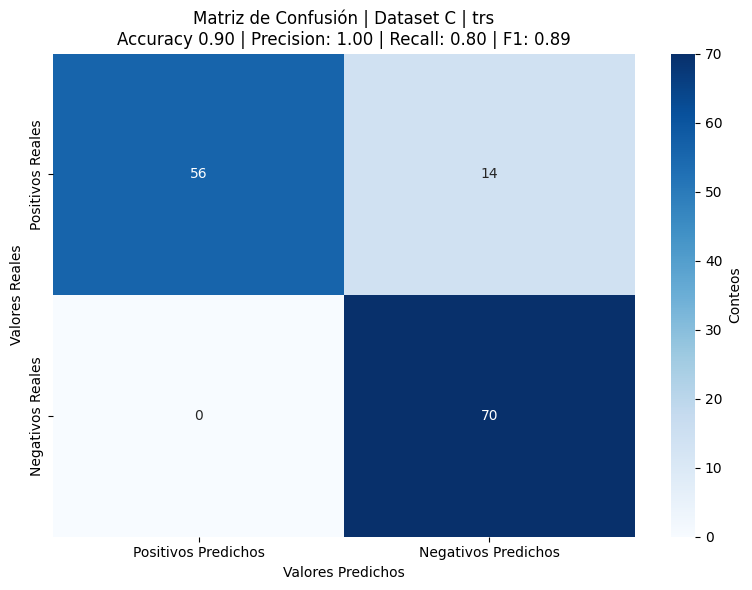

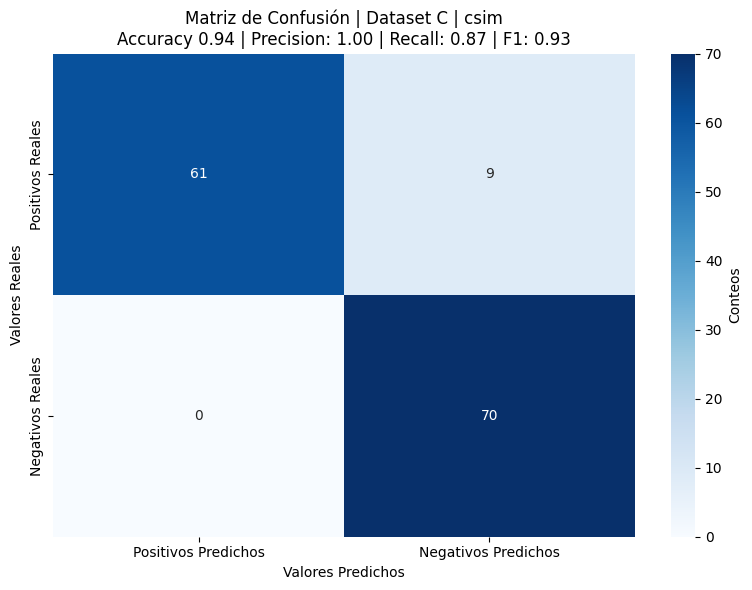

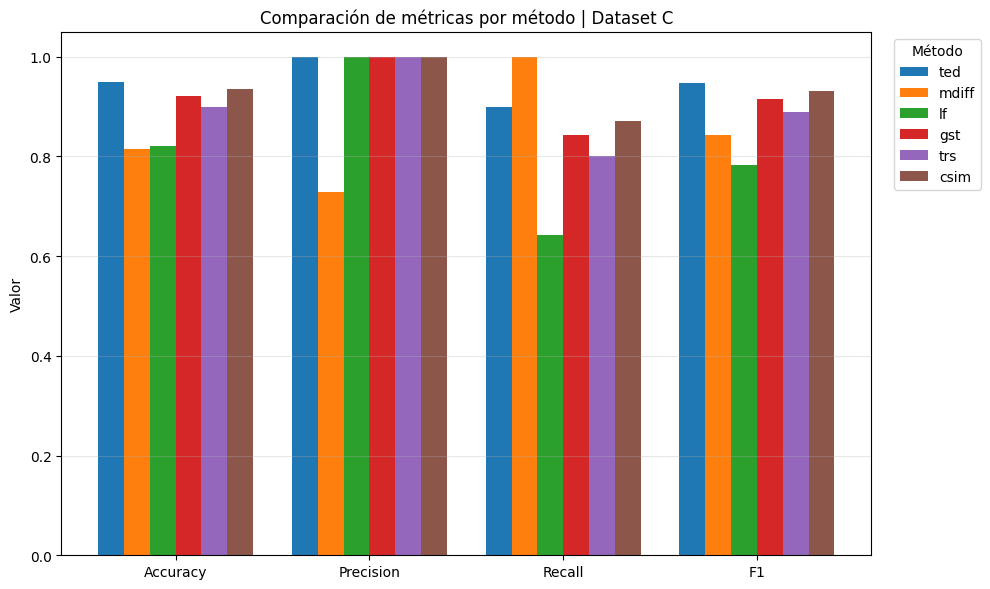

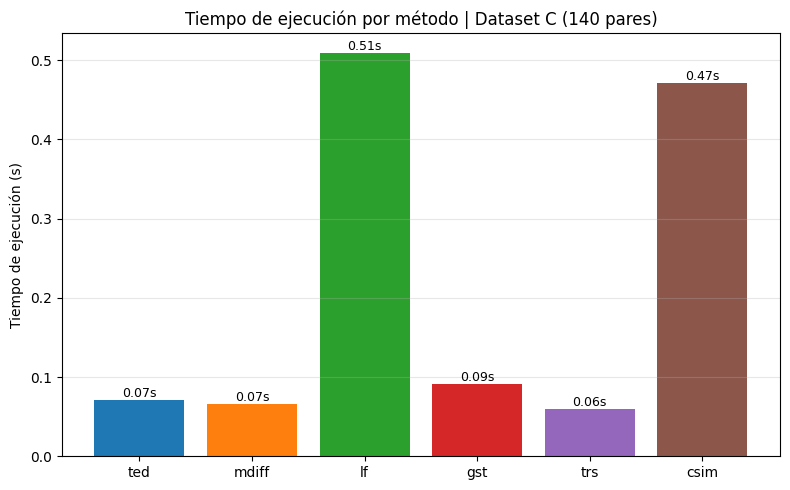

In [10]:
_ = run_dataset_evaluation("C")

## Dataset D

=== Dataset D ===
Dataset D: 290/290 pares verificados positivamente (usables).


  ted   :   0.27s  (19 pares mal clasificados)


  mdiff :   0.35s  (9 pares mal clasificados)


  lf    :   1.26s  (33 pares mal clasificados)


  gst   :   0.62s  (34 pares mal clasificados)


  trs   :   0.26s  (42 pares mal clasificados)


  csim  :   4.55s  (29 pares mal clasificados)


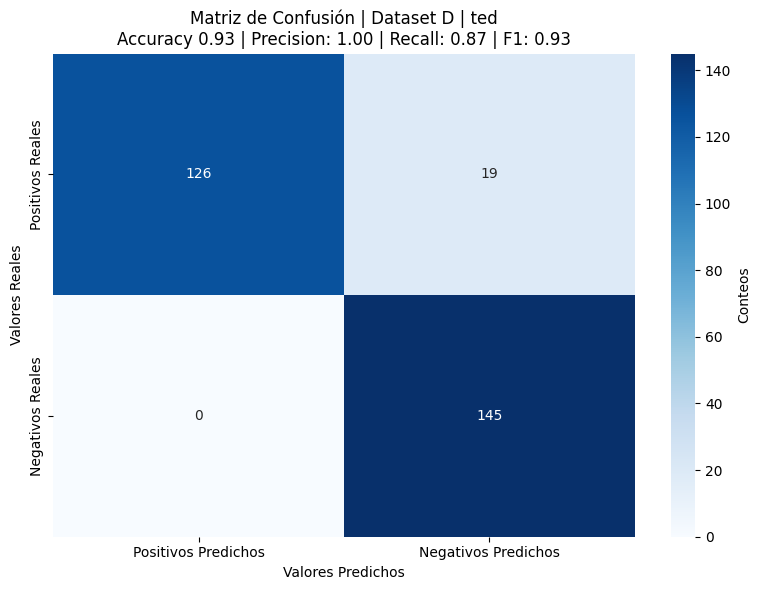

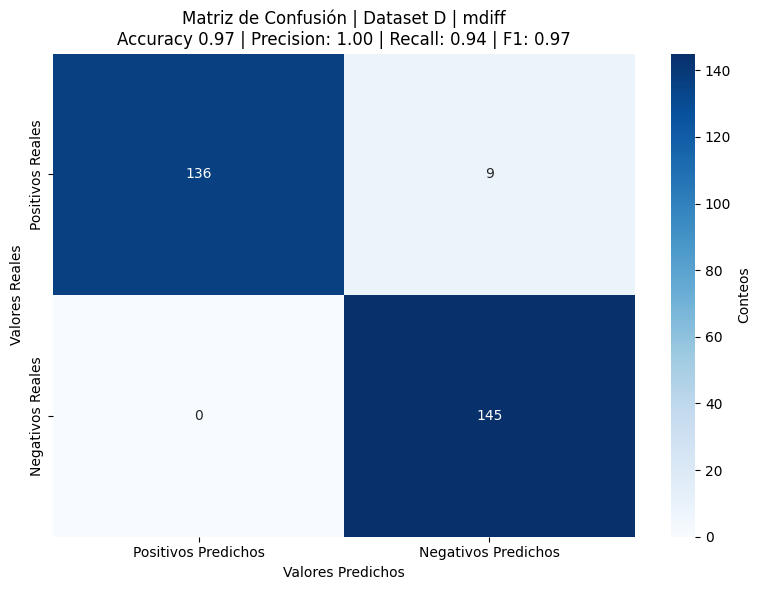

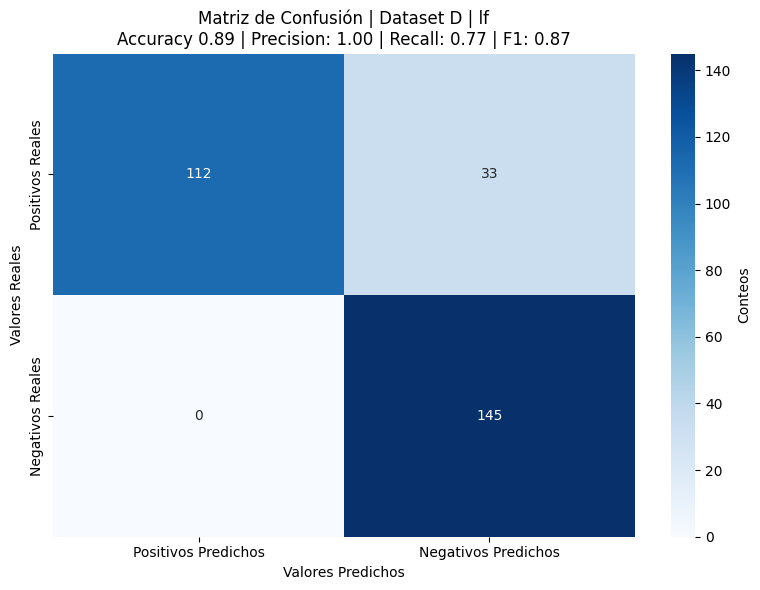

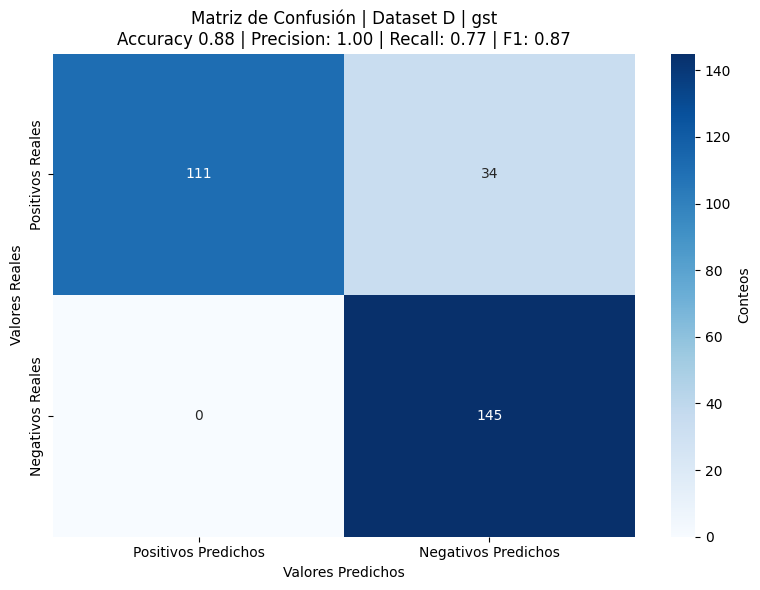

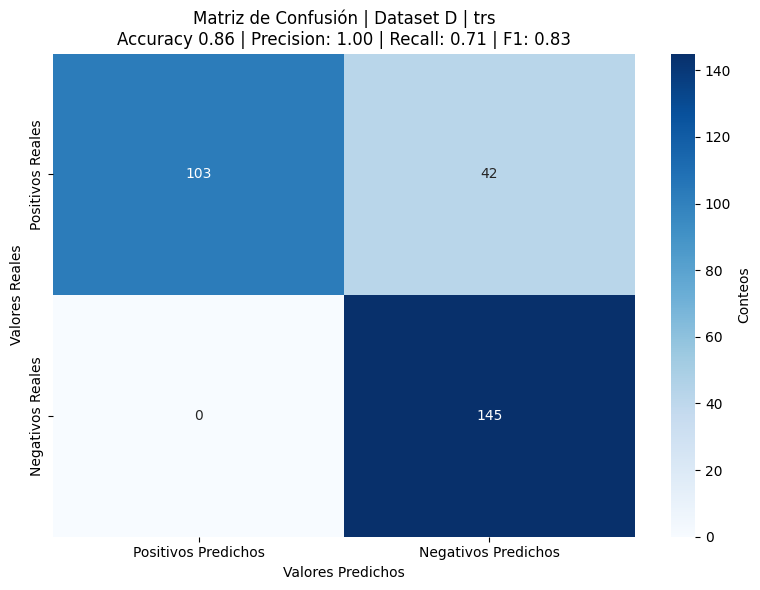

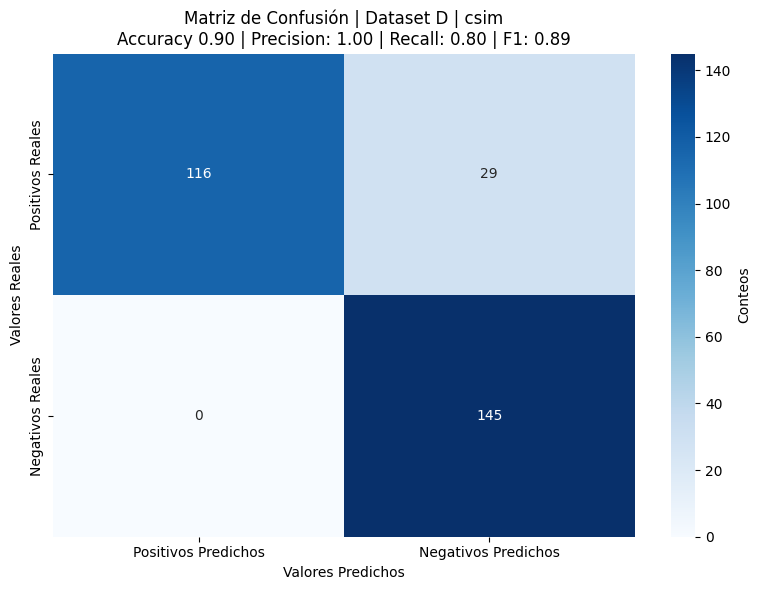

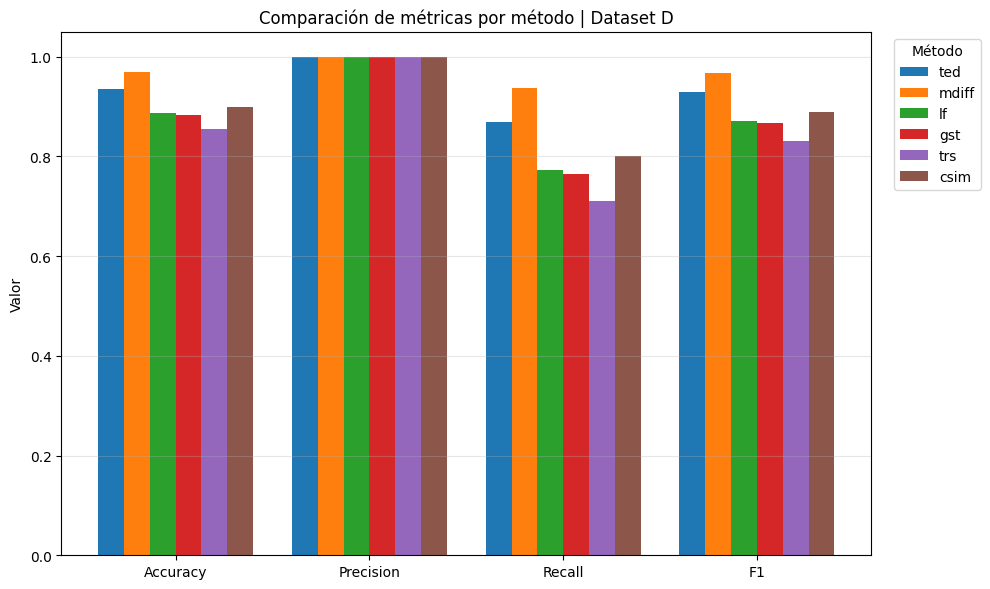

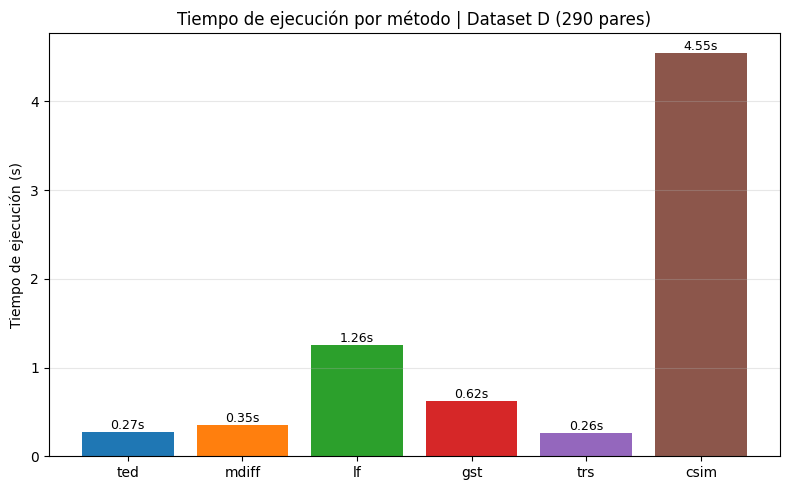

In [11]:
_ = run_dataset_evaluation("D")

## Dataset E

=== Dataset E ===
Dataset E: 468/468 pares verificados positivamente (usables).


  ted   :   0.71s  (45 pares mal clasificados)


  mdiff :   1.17s  (12 pares mal clasificados)


  lf    :   2.50s  (56 pares mal clasificados)


  gst   :   2.88s  (56 pares mal clasificados)


  trs   :   0.72s  (77 pares mal clasificados)


Syntax error in file None line 9:0  LEXER ERROR: inconsistent use of tabs and spaces in indentation
Syntax error in file None line 9:1 mismatched input ' ERROR: inconsistent use of tabs and spaces in indentation' expecting INDENT
Syntax error in file None line 10:1 mismatched input '<INDENT>' expecting <EOF>
Syntax error in file None line 9:0  LEXER ERROR: inconsistent use of tabs and spaces in indentation
Syntax error in file None line 9:1 mismatched input ' ERROR: inconsistent use of tabs and spaces in indentation' expecting INDENT
Syntax error in file None line 10:1 mismatched input '<INDENT>' expecting <EOF>


Syntax error in file None line 9:0  LEXER ERROR: inconsistent use of tabs and spaces in indentation
Syntax error in file None line 9:1 mismatched input ' ERROR: inconsistent use of tabs and spaces in indentation' expecting INDENT
Syntax error in file None line 10:1 mismatched input '<INDENT>' expecting <EOF>


  csim  :  12.57s  (44 pares mal clasificados)


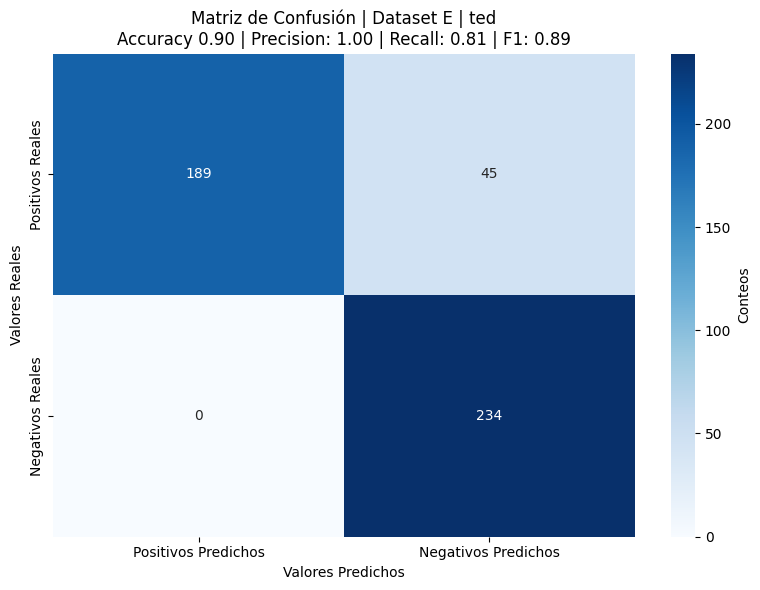

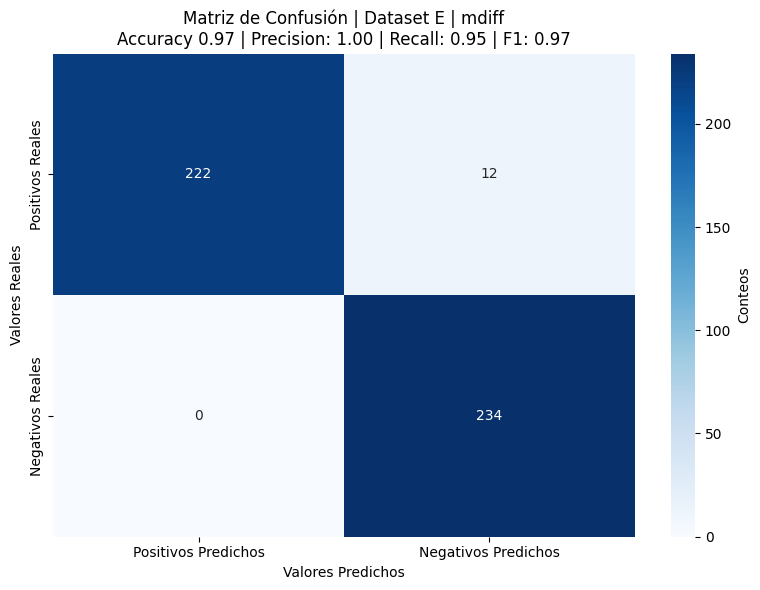

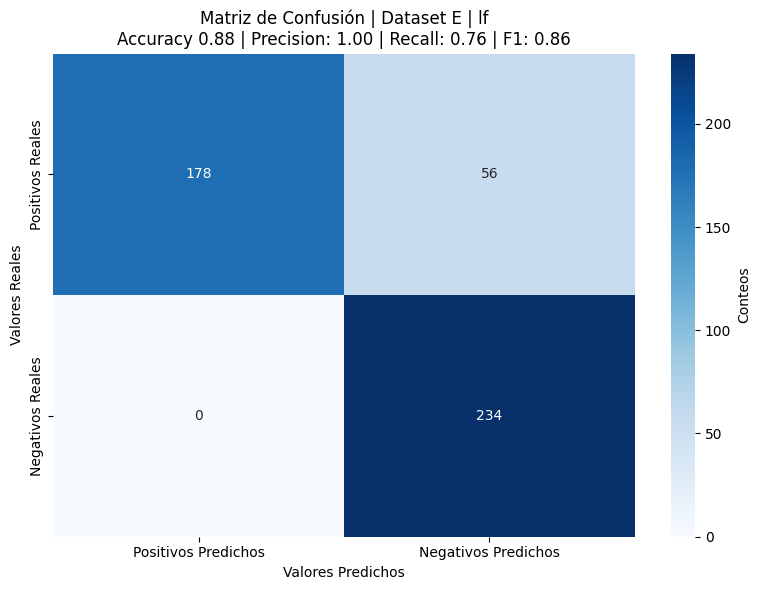

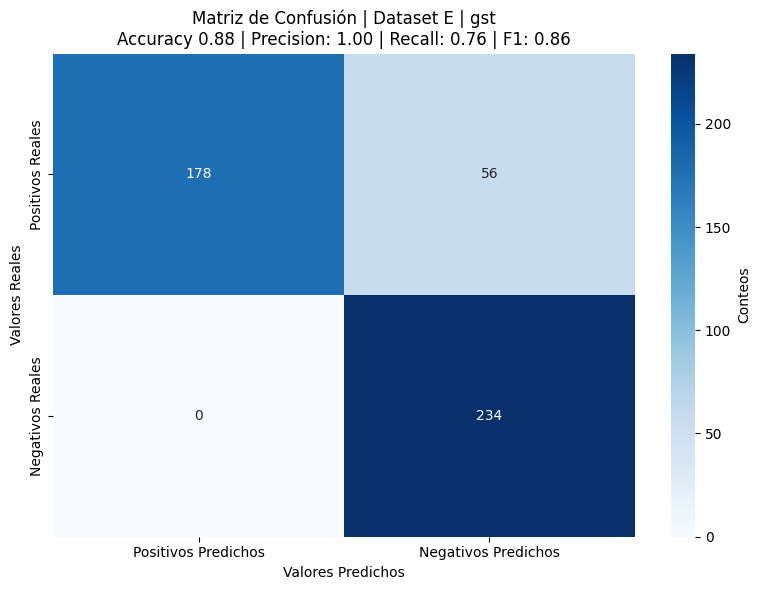

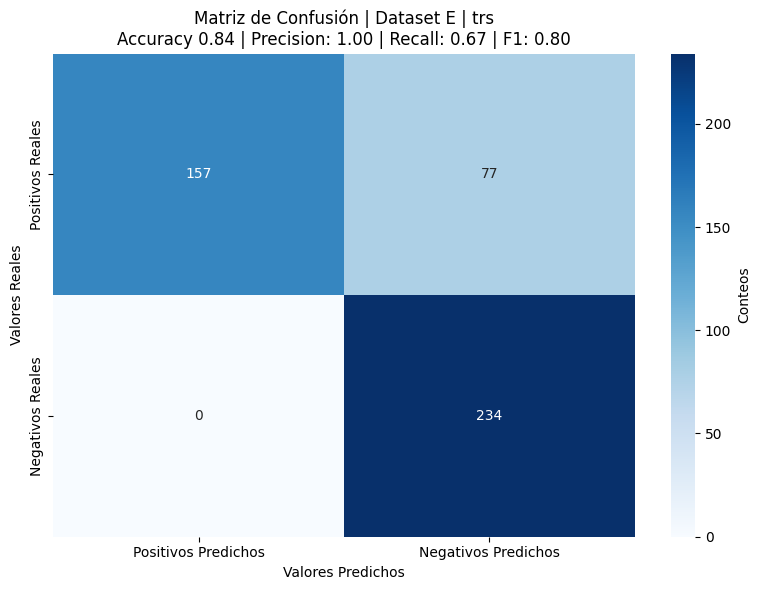

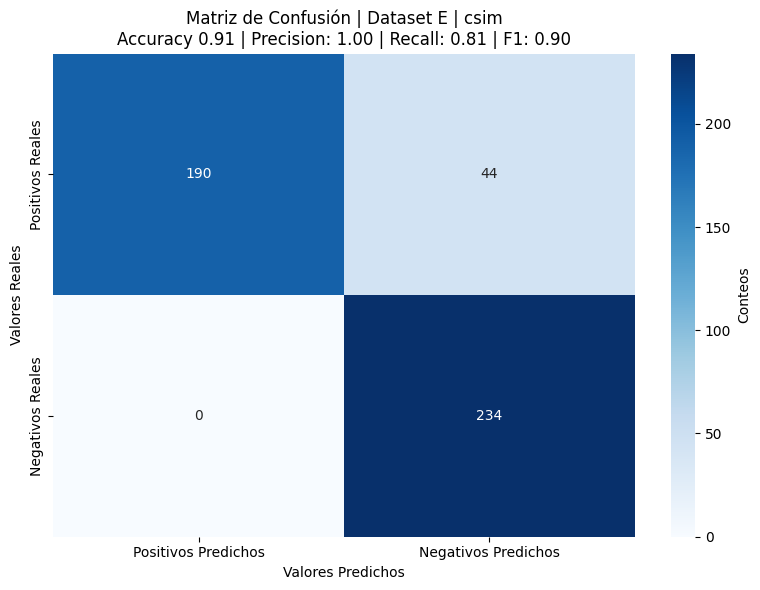

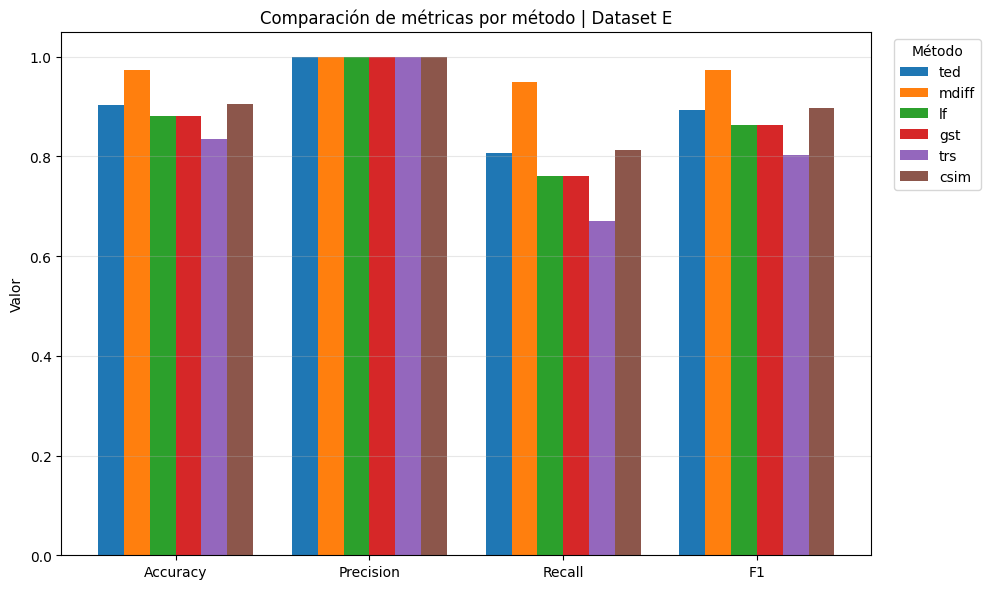

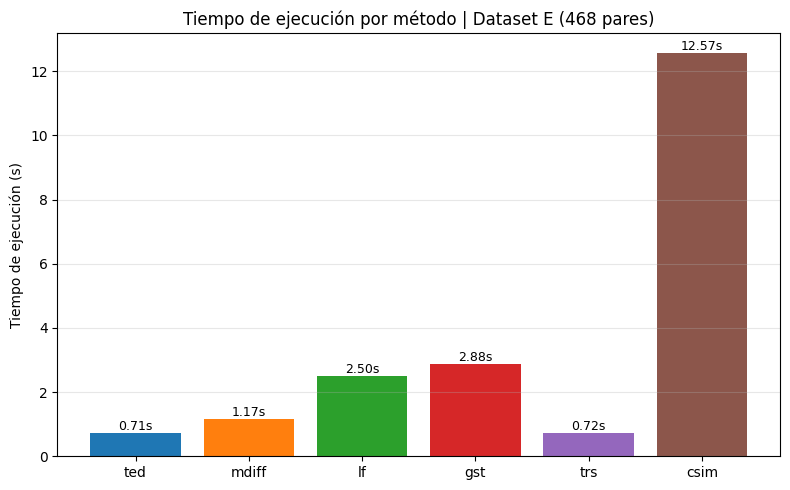

In [12]:
_ = run_dataset_evaluation("E")

## Resumen general

Comparación agregada de los 6 métodos a través de los 5 datasets: F1 por
dataset y método, promedio de métricas, y tiempo total de ejecución.

In [13]:
def plot_summary_heatmap(all_results):
    dataset_letters = list(all_results.keys())
    rows = []
    for ds in dataset_letters:
        row = []
        for m in METHODS:
            _, _, _, _, f1 = calculate_metrics(all_results[ds][m]["truth"], all_results[ds][m]["pred"])
            row.append(f1)
        rows.append(row)

    df_f1 = pd.DataFrame(rows, index=[f"Dataset {d}" for d in dataset_letters], columns=METHODS)

    plt.figure(figsize=(9, 6))
    sns.heatmap(df_f1, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar_kws={"label": "F1-score"})
    plt.title("F1-score por método y dataset")
    plt.tight_layout()
    plt.show()
    return df_f1


def plot_overall_method_comparison(all_results):
    """Promedio de cada métrica por método, a través de los 5 datasets."""
    metrics_names = ["Accuracy", "Precision", "Recall", "F1"]
    avg_data = {}
    for m in METHODS:
        accs, precs, recs, f1s = [], [], [], []
        for ds in all_results:
            _, acc, prec, rec, f1 = calculate_metrics(all_results[ds][m]["truth"], all_results[ds][m]["pred"])
            accs.append(acc); precs.append(prec); recs.append(rec); f1s.append(f1)
        avg_data[m] = [np.mean(accs), np.mean(precs), np.mean(recs), np.mean(f1s)]

    x = np.arange(len(metrics_names))
    width = 0.8 / len(METHODS)

    plt.figure(figsize=(10, 6))
    for i, m in enumerate(METHODS):
        plt.bar(x + i * width, avg_data[m], width, label=m, color=METHOD_COLORS.get(m))

    plt.xticks(x + width * (len(METHODS) - 1) / 2, metrics_names)
    plt.ylim(0, 1.05)
    plt.ylabel("Promedio sobre los 5 datasets")
    plt.title("Comparación general de métodos (promedio en los 5 datasets)")
    plt.legend(title="Método", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_overall_time_comparison(all_results):
    totals = [sum(all_results[ds][m]["time"] for ds in all_results) for m in METHODS]
    colors = [METHOD_COLORS.get(m) for m in METHODS]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(METHODS, totals, color=colors)
    plt.ylabel("Tiempo total (s)")
    plt.title("Tiempo total de ejecución por método (suma de los 5 datasets)")
    for b, t in zip(bars, totals):
        plt.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{t:.2f}s", ha="center", va="bottom", fontsize=9)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


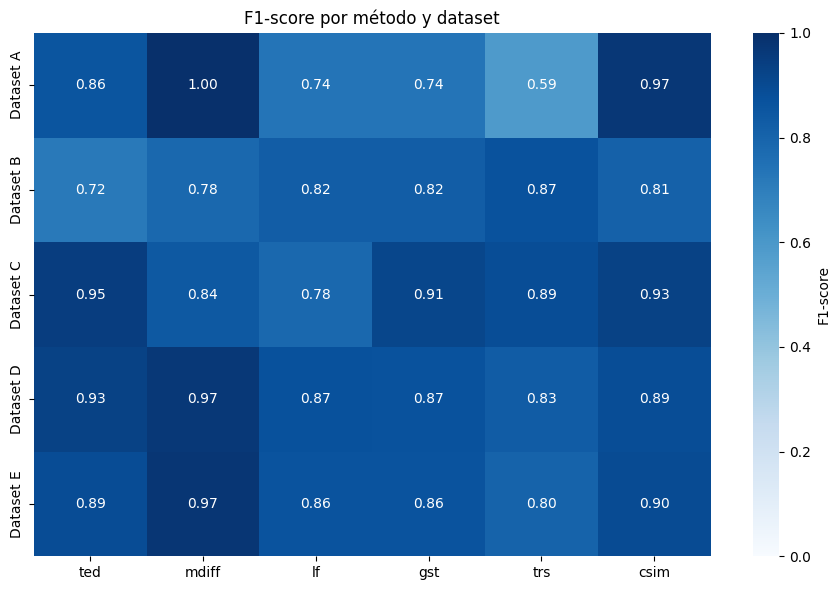

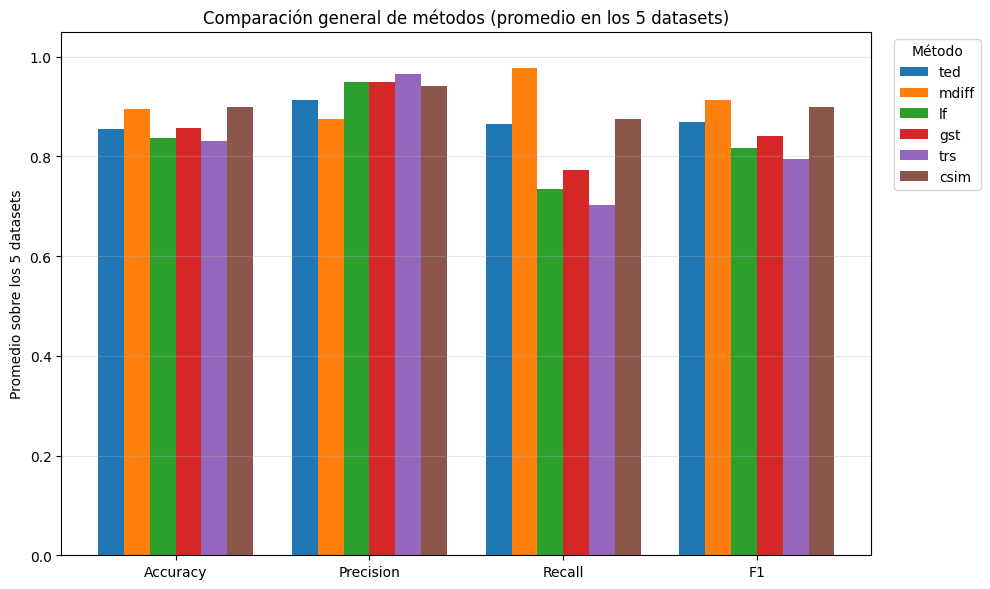

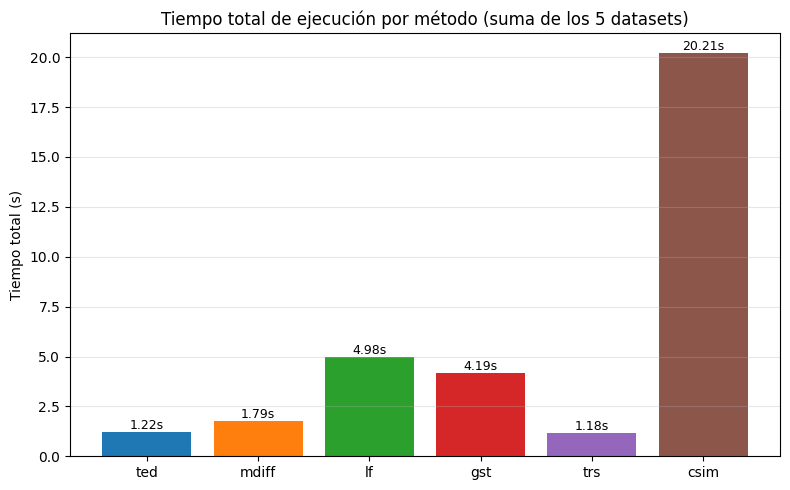

In [14]:
_ = plot_summary_heatmap(all_results)
plot_overall_method_comparison(all_results)
plot_overall_time_comparison(all_results)
